# **Import Libraries**

In [261]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# **Load the Dataset**

In [262]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# **Data Exploration**


In [263]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [264]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [265]:
df.shape

(5110, 12)

In [266]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [267]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [268]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [269]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [270]:
df.describe(include='object').T

,count,unique,top,freq
gender,5110,3,Female,2994
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
smoking_status,5110,4,never smoked,1892


In [271]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

In [272]:
for col in df.columns:
    print(col)
    print(df[col].value_counts())
    print("=" * 60)

id
id
9046     1
51676    1
31112    1
60182    1
1665     1
        ..
18234    1
44873    1
19723    1
37544    1
44679    1
Name: count, Length: 5110, dtype: int64
gender
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
age
age
78.00    102
57.00     95
52.00     90
54.00     87
51.00     86
        ... 
1.40       3
0.48       3
0.16       3
0.40       2
0.08       2
Name: count, Length: 104, dtype: int64
hypertension
hypertension
0    4612
1     498
Name: count, dtype: int64
heart_disease
heart_disease
0    4834
1     276
Name: count, dtype: int64
ever_married
ever_married
Yes    3353
No     1757
Name: count, dtype: int64
work_type
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64
Residence_type
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64
avg_glucose_level
avg_glucose_level
93.88     6
73.00     5
72.49     5
91.68     5
91.85     5


In [273]:
df['gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

In [274]:
df['hypertension'].unique()

array([0, 1])

In [275]:
df['heart_disease'].unique()

array([1, 0])

In [276]:
df['ever_married'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [277]:
df['work_type'].unique()

<ArrowStringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str

In [278]:
df['Residence_type'].unique()

<ArrowStringArray>
['Urban', 'Rural']
Length: 2, dtype: str

In [279]:
df['smoking_status'].unique()

<ArrowStringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str

In [280]:
df['stroke'].unique()

array([1, 0])

# **Handle Missing Values**

In [281]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [282]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

bmi    201
dtype: int64

In [283]:
df.isnull().sum().sum()

np.int64(201)

In [284]:
(df.isnull().mean()*100).sort_values(ascending=False)

bmi                  3.933464
id                   0.000000
age                  0.000000
gender               0.000000
hypertension         0.000000
heart_disease        0.000000
work_type            0.000000
ever_married         0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
smoking_status       0.000000
stroke               0.000000
dtype: float64

In [285]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

bmi    3.933464
dtype: float64

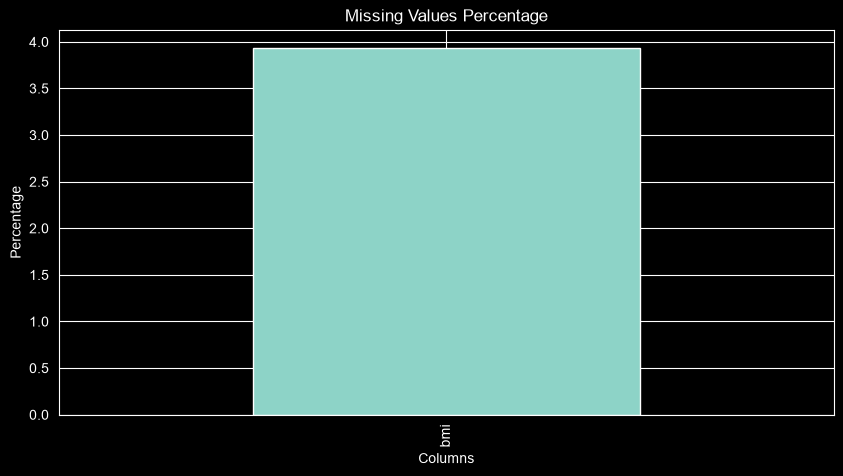

In [286]:
plt.figure(figsize=(10, 5))

missing_percentage[missing_percentage > 0].plot(kind='bar')

plt.title("Missing Values Percentage")
plt.xlabel("Columns")
plt.ylabel("Percentage")

plt.show()

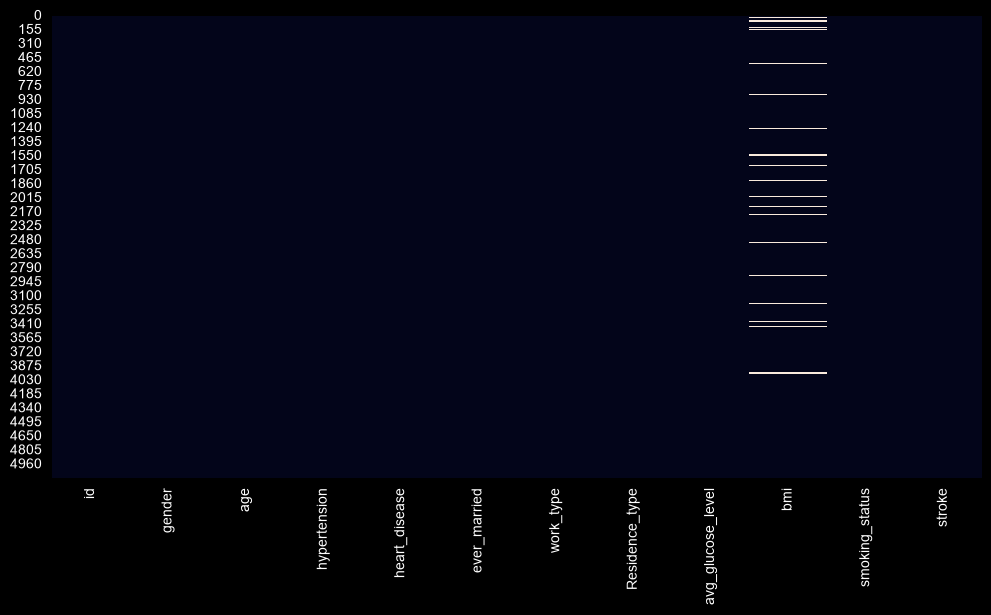

In [287]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.show()

In [288]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [289]:
df.isnull().sum().sum()

np.int64(0)

# **Remove Duplicates**


In [290]:
df.duplicated().sum()

np.int64(0)

In [291]:
df.drop_duplicates(inplace=True)

In [292]:
df.duplicated().sum()

np.int64(0)

# **Invalid Value Detection**

In [293]:
df[(df['age'] < 0) | (df['age'] > 120)]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [294]:
df[(df['bmi'] <= 0) | (df['bmi'] > 80)]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2128,56420,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0
4209,51856,Male,38.0,1,0,Yes,Private,Rural,56.90,92.0,never smoked,0


In [295]:
df[(df['avg_glucose_level'] < 30) | (df['avg_glucose_level'] > 600)]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [296]:
df[~df['hypertension'].isin([0, 1])]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [297]:
df[~df['heart_disease'].isin([0, 1])]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [298]:
df[~df['stroke'].isin([0, 1])]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


# **Outlier Detection**

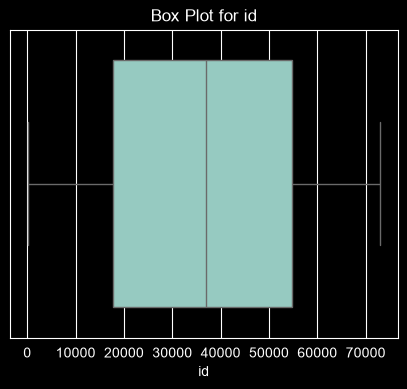

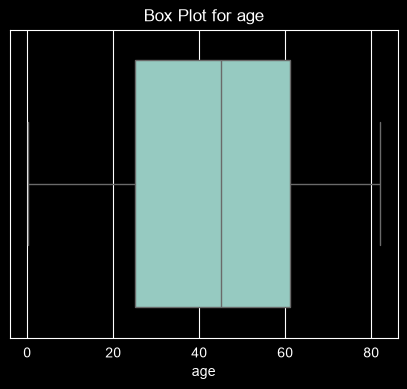

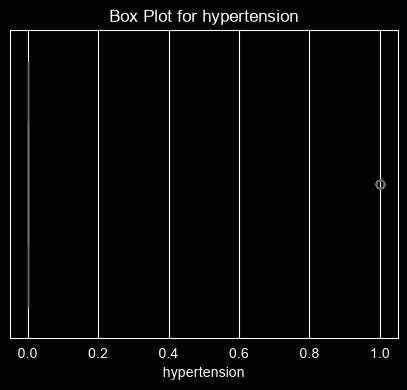

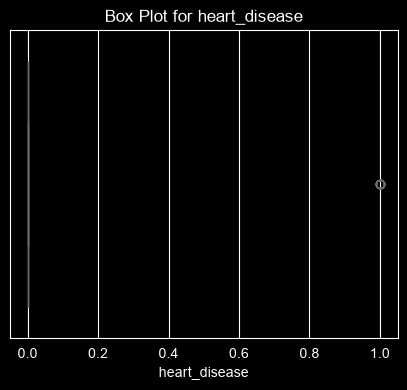

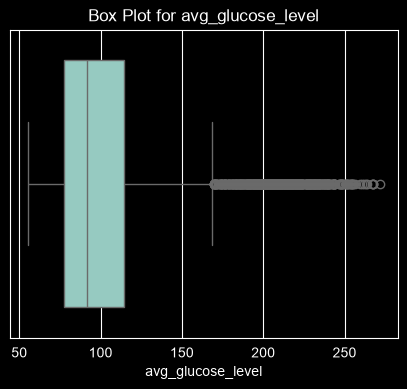

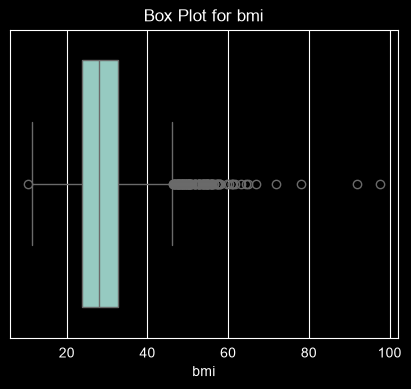

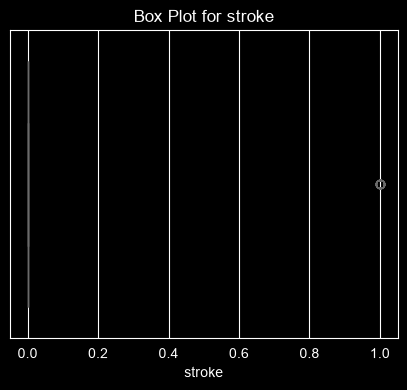

In [299]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot for {col}')
    plt.show()

In [300]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
            (df[num_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()

id                     0
age                    0
hypertension         498
heart_disease        276
avg_glucose_level    627
bmi                  126
stroke               249
dtype: int64

In [301]:
(outliers.sum() / len(df)) * 100

id                    0.000000
age                   0.000000
hypertension          9.745597
heart_disease         5.401174
avg_glucose_level    12.270059
bmi                   2.465753
stroke                4.872798
dtype: float64

In [302]:
outliers.sum().sum()

np.int64(1776)

# **Encoding**

In [303]:
df['gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

In [304]:
df['gender'] = df['gender'].map({
    'Male': 0,
    'Female': 1
})

In [305]:
df['gender'].unique()

array([ 0.,  1., nan])

In [306]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [307]:
df['gender'].unique()

array([0., 1.])

In [308]:
df['ever_married'].unique()

<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

In [309]:
df['ever_married'] = df['ever_married'].map({
    'No': 0,
    'Yes': 1
})

In [310]:
df['ever_married'].unique()

array([1, 0])

In [311]:
cols = [
    'work_type',
    'Residence_type',
    'smoking_status'
]

df = pd.get_dummies(
    df,
    columns=cols,
    drop_first=True
)

In [312]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [313]:
df.dtypes

id                                  int64
gender                            float64
age                               float64
hypertension                        int64
heart_disease                       int64
ever_married                        int64
avg_glucose_level                 float64
bmi                               float64
stroke                              int64
work_type_Never_worked              int64
work_type_Private                   int64
work_type_Self-employed             int64
work_type_children                  int64
Residence_type_Urban                int64
smoking_status_formerly smoked      int64
smoking_status_never smoked         int64
smoking_status_smokes               int64
dtype: object

In [314]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# **Transformation**

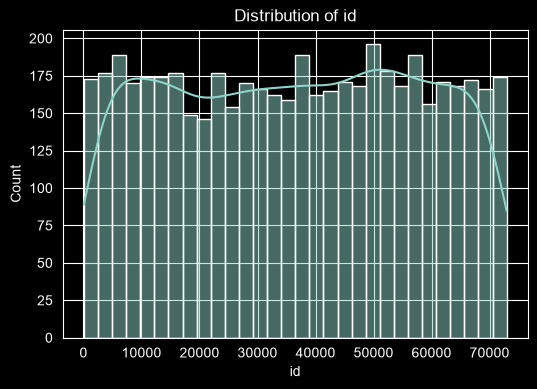

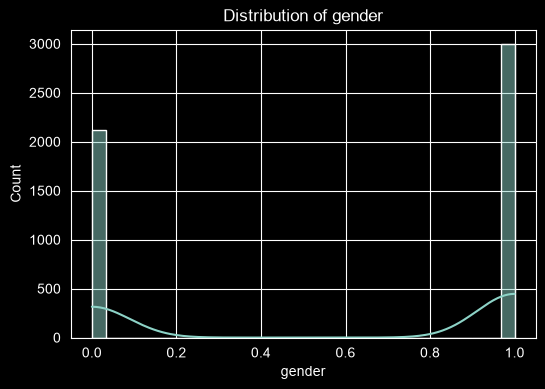

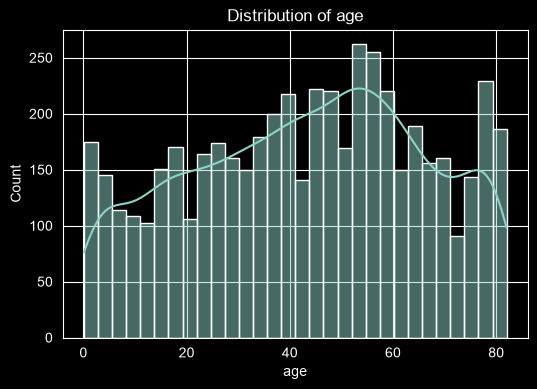

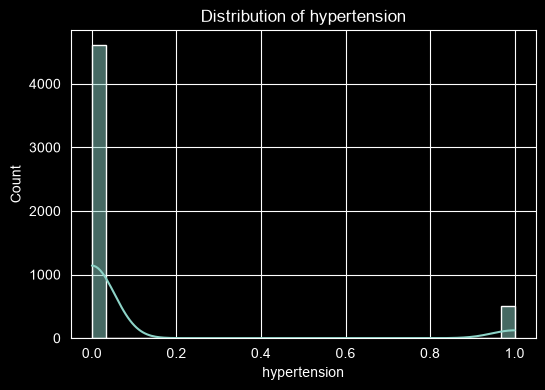

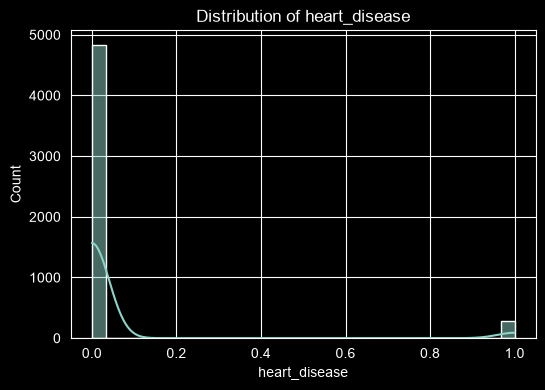

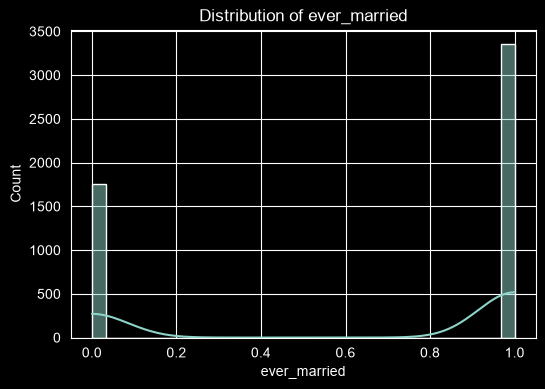

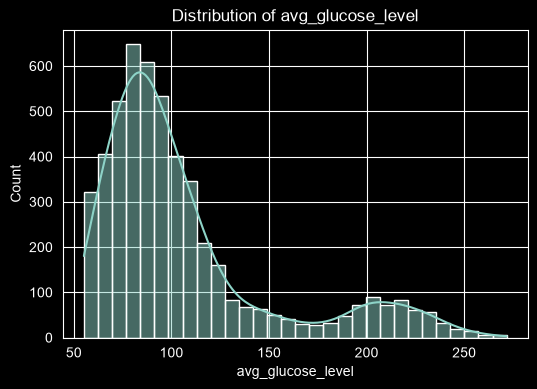

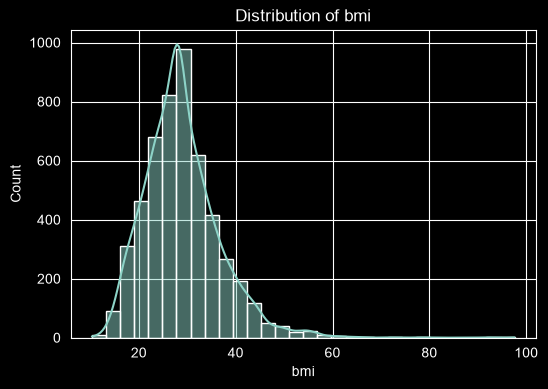

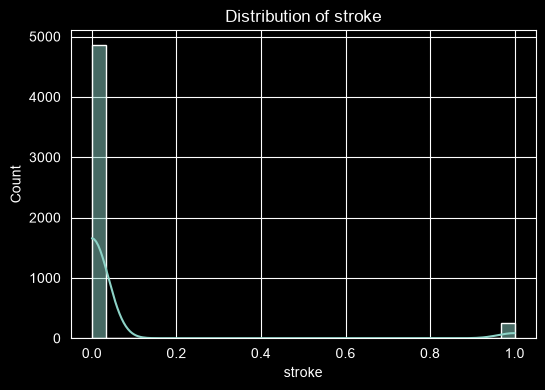

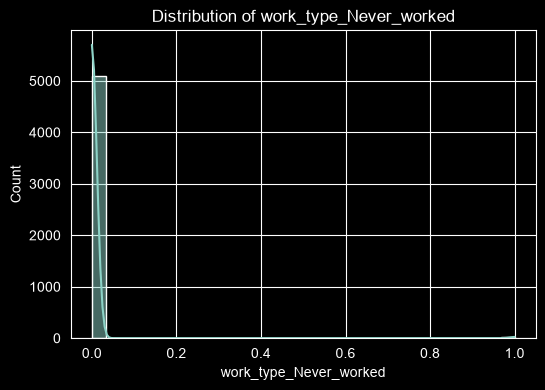

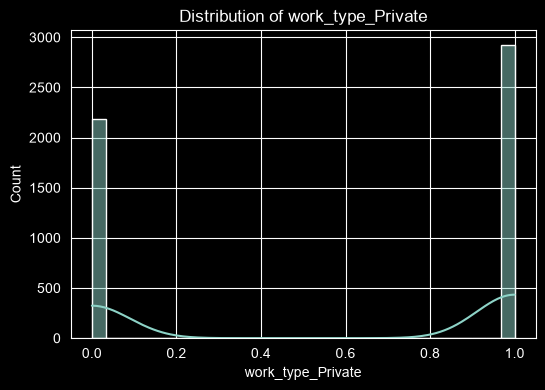

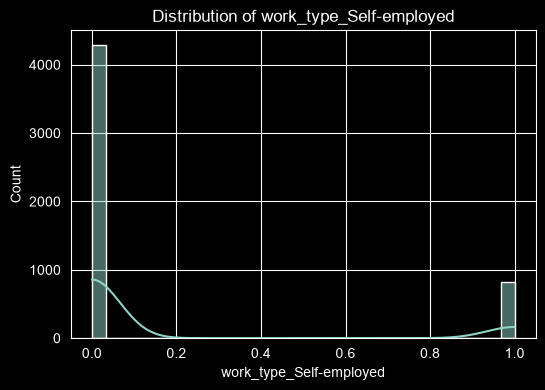

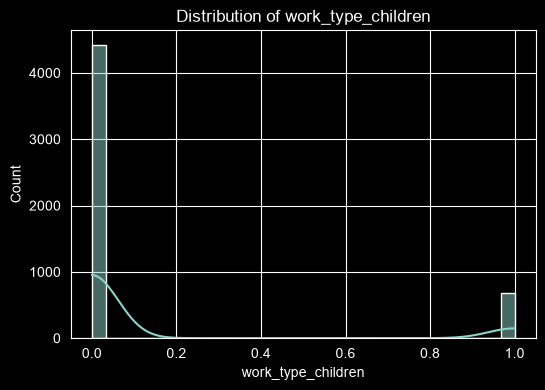

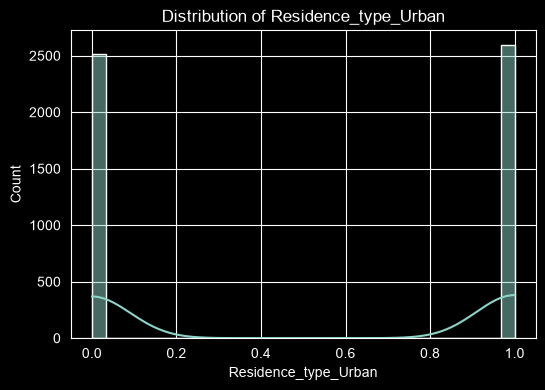

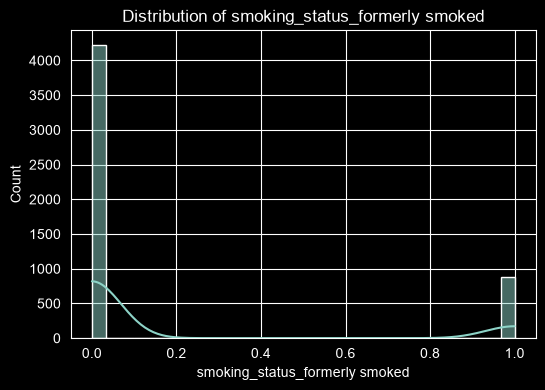

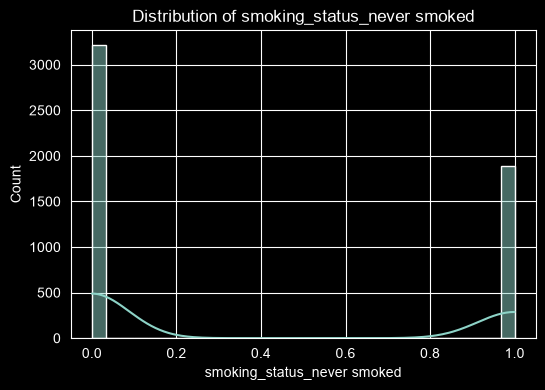

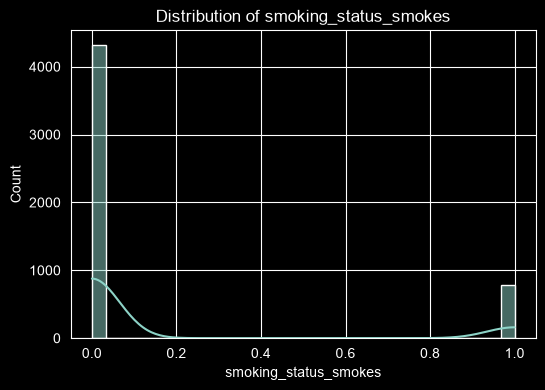

In [315]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [316]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)

print(skewness)

work_type_Never_worked            15.146344
stroke                             4.193284
heart_disease                      3.947244
hypertension                       2.715392
work_type_children                 2.143866
smoking_status_smokes              1.913452
work_type_Self-employed            1.852619
smoking_status_formerly smoked     1.727782
avg_glucose_level                  1.572284
bmi                                1.088187
smoking_status_never smoked        0.537548
id                                -0.019913
Residence_type_Urban              -0.032107
age                               -0.137059
work_type_Private                 -0.292800
gender                            -0.349749
ever_married                      -0.657745
dtype: float64


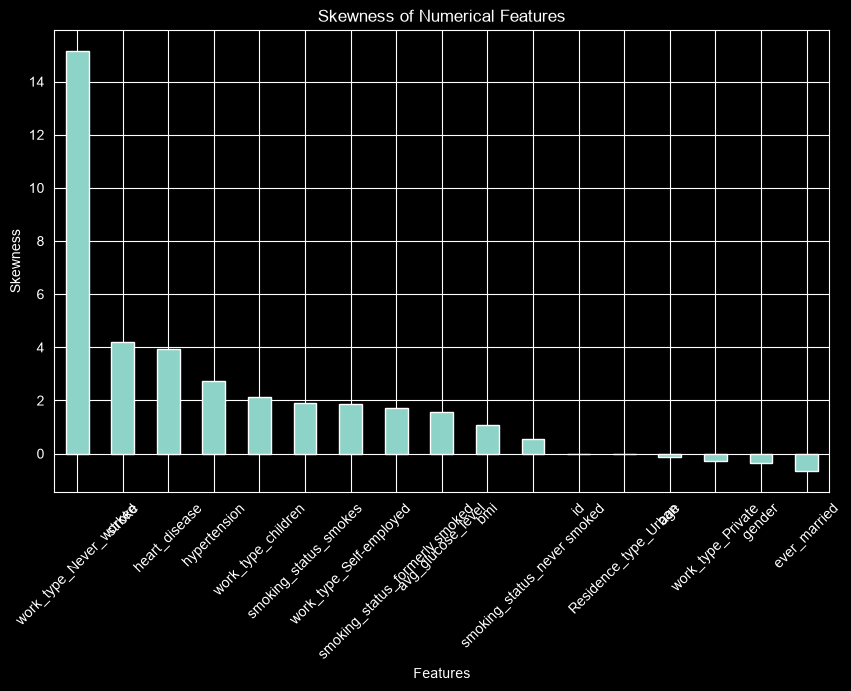

In [317]:
plt.figure(figsize=(10,6))

skewness.plot(kind='bar')

plt.title("Skewness of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Skewness")

plt.xticks(rotation=45)
plt.show()

In [318]:
log_cols = [
    'avg_glucose_level',
    'bmi'
]

In [319]:
for col in log_cols:
    df[col] = np.log1p(df[col])

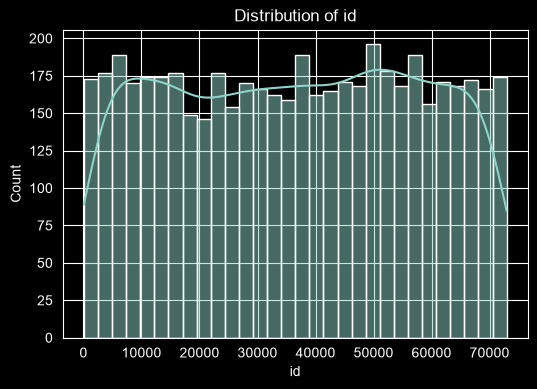

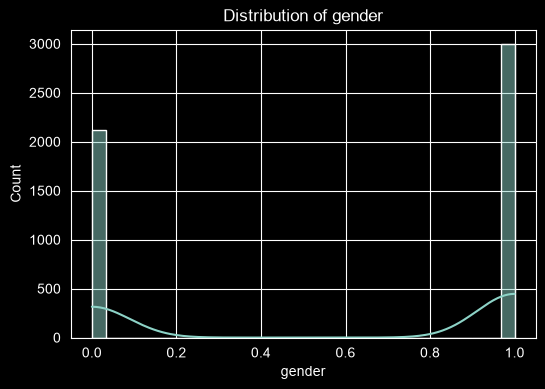

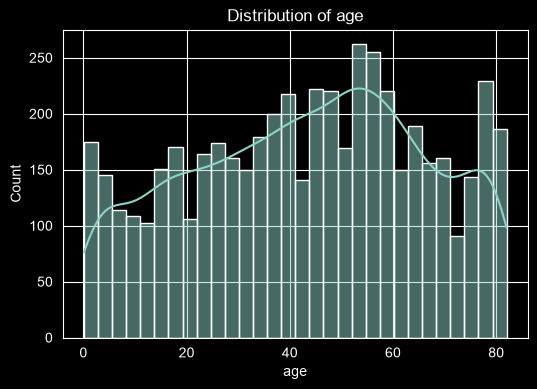

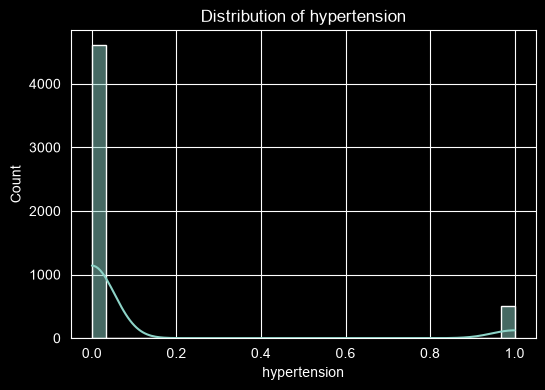

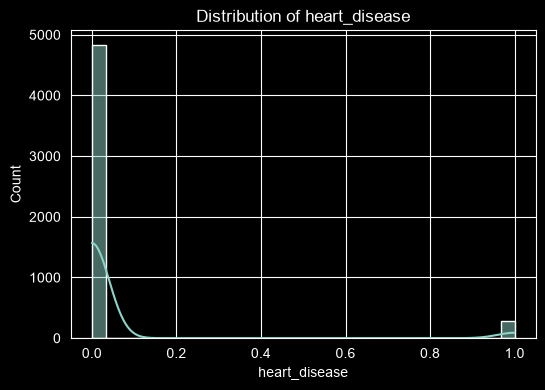

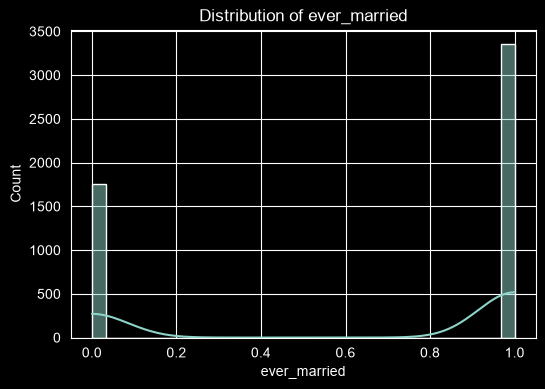

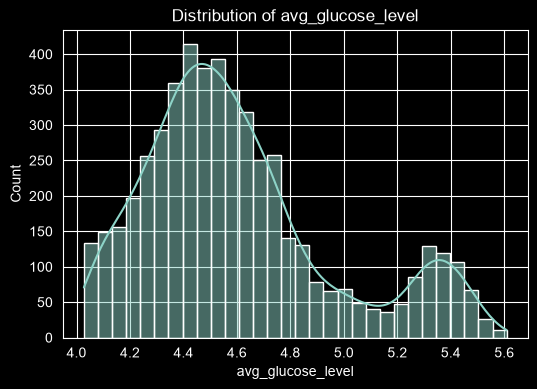

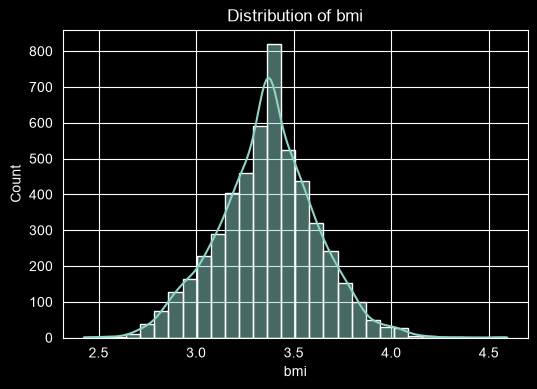

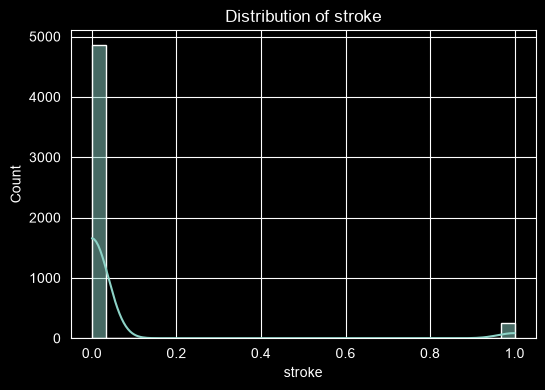

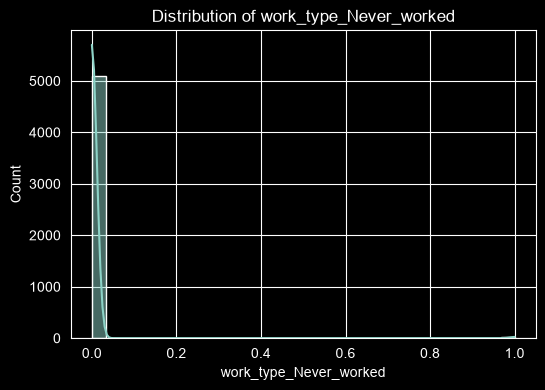

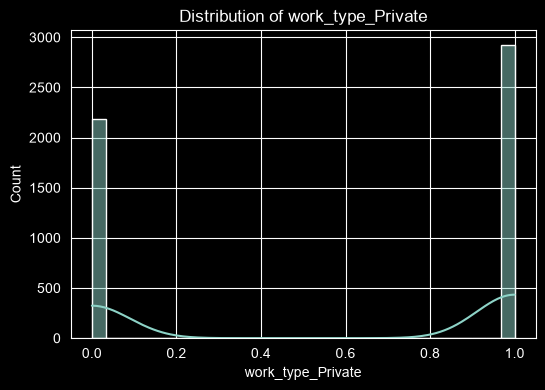

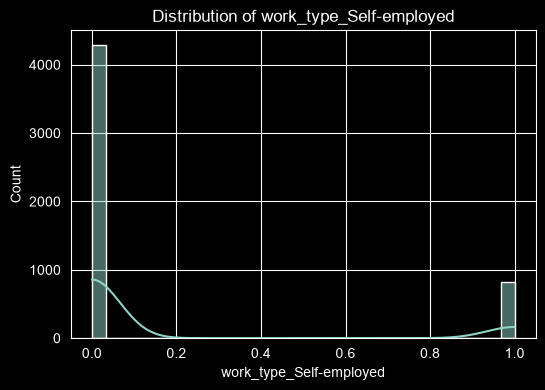

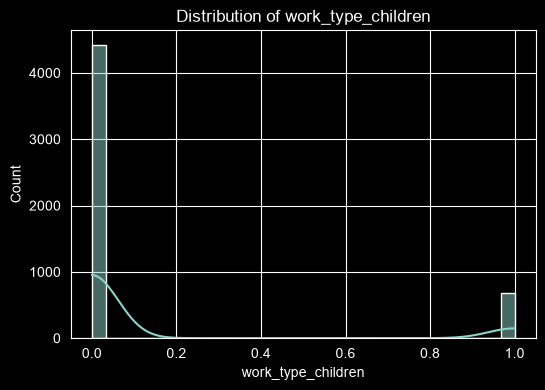

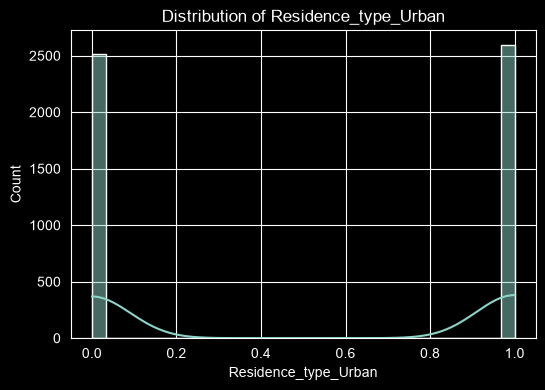

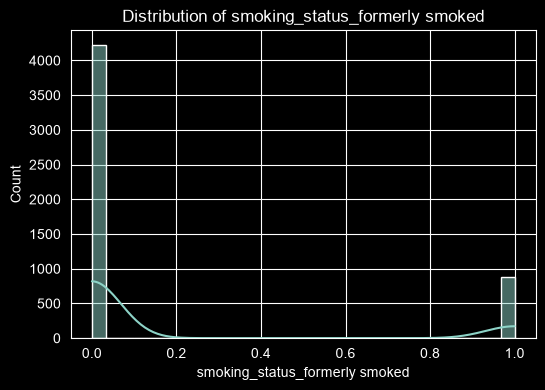

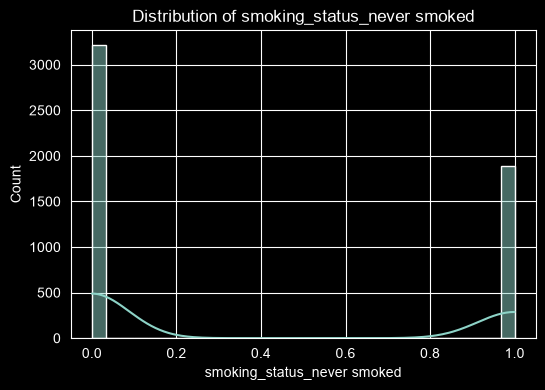

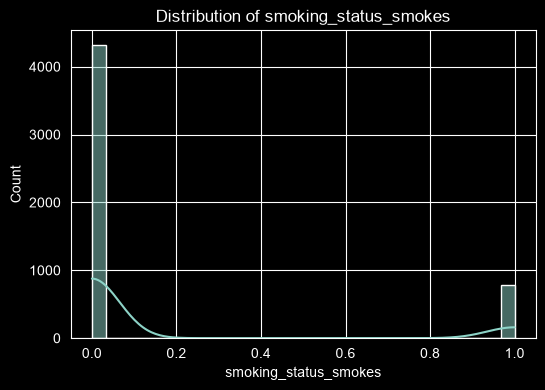

In [320]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# **Exploratory Data Analysis (EDA)**

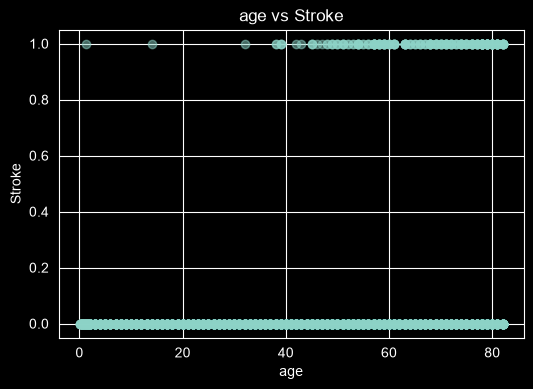

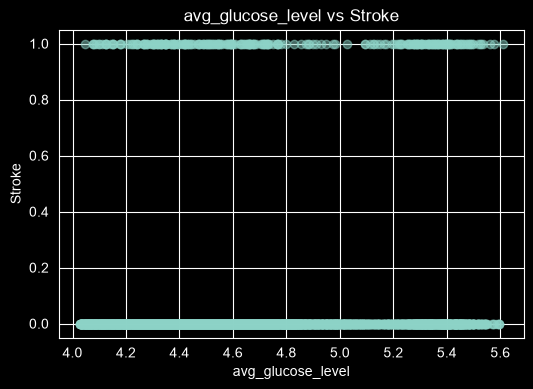

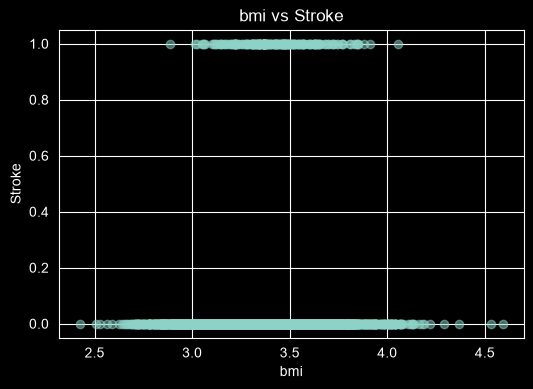

In [321]:
cols = [
    'age',
    'avg_glucose_level',
    'bmi'
]

for col in cols:
    plt.figure(figsize=(6, 4))

    plt.scatter(df[col], df["stroke"], alpha=0.5)

    plt.xlabel(col)
    plt.ylabel("Stroke")
    plt.title(f"{col} vs Stroke")

    plt.show()

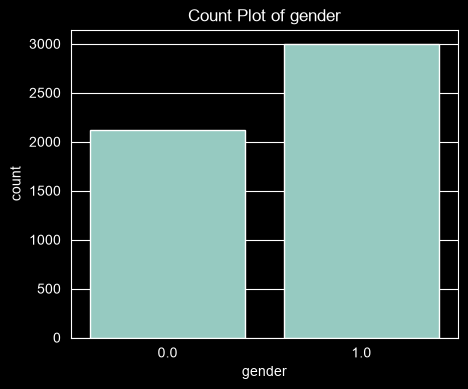

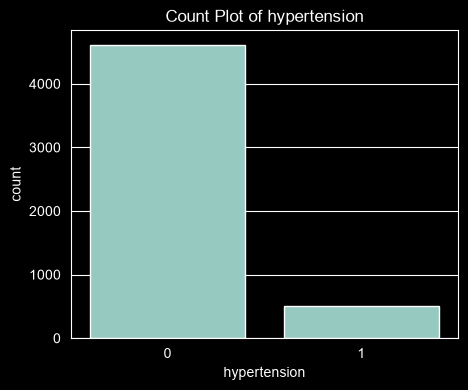

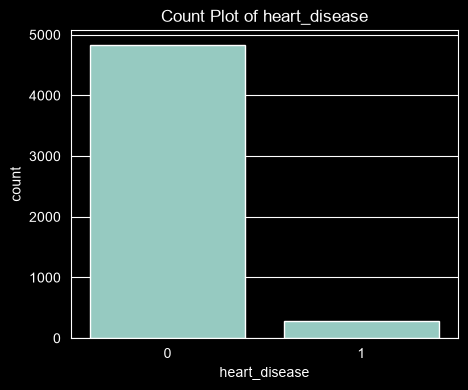

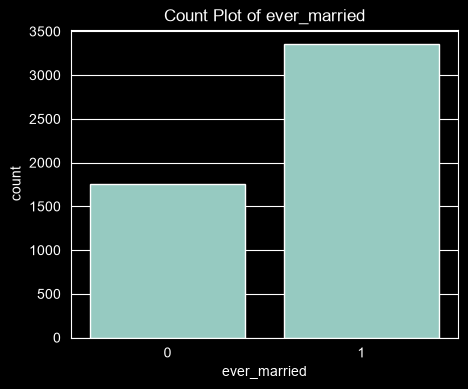

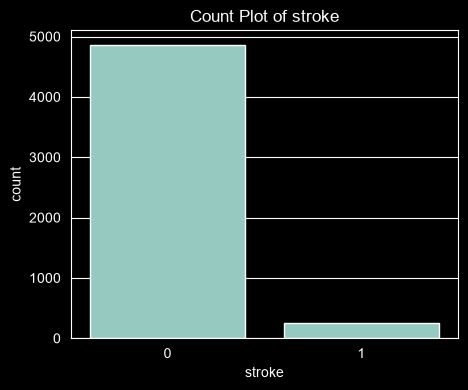

In [322]:
binary_cols = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "stroke"
]

for col in binary_cols:
    plt.figure(figsize=(5, 4))

    sns.countplot(x=col, data=df)

    plt.title(f"Count Plot of {col}")

    plt.show()

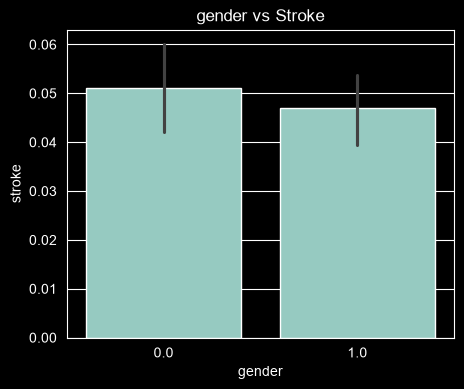

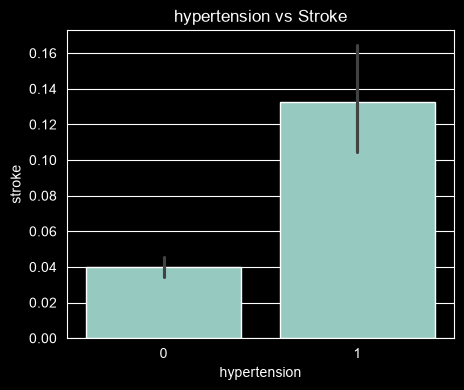

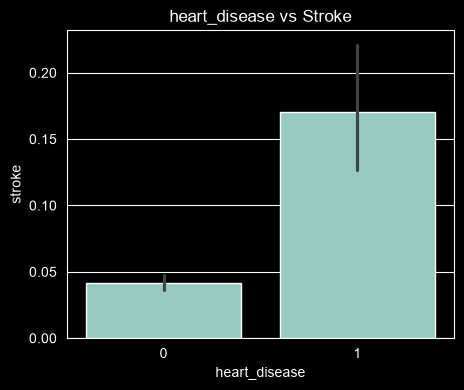

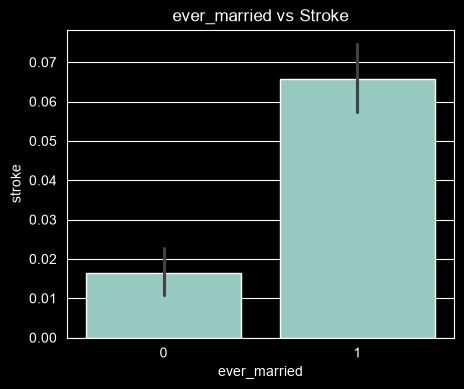

In [323]:
binary_cols.remove("stroke")

for col in binary_cols:
    plt.figure(figsize=(5, 4))

    sns.barplot(
        x=col,
        y="stroke",
        data=df
    )

    plt.title(f"{col} vs Stroke")

    plt.show()

In [324]:
for col in binary_cols:
    print(pd.crosstab(df[col], df["stroke"]))

    print("=" * 50)

stroke     0    1
gender           
0.0     2007  108
1.0     2854  141
stroke           0    1
hypertension           
0             4429  183
1              432   66
stroke            0    1
heart_disease           
0              4632  202
1               229   47
stroke           0    1
ever_married           
0             1728   29
1             3133  220


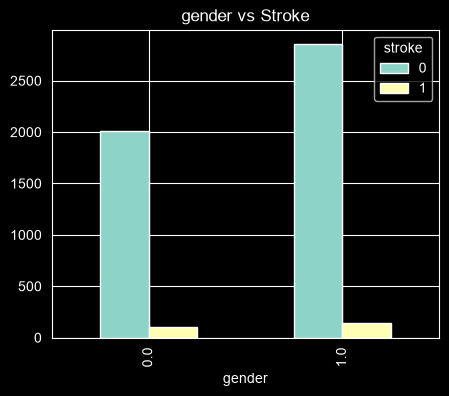

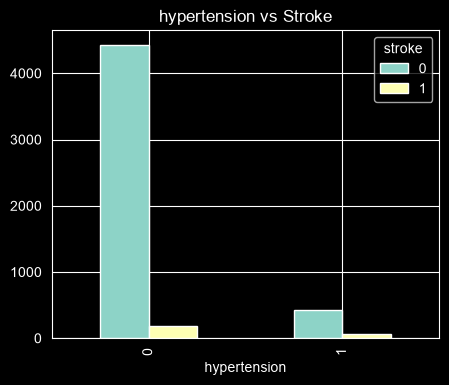

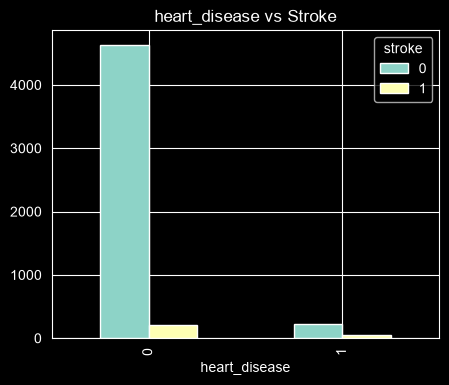

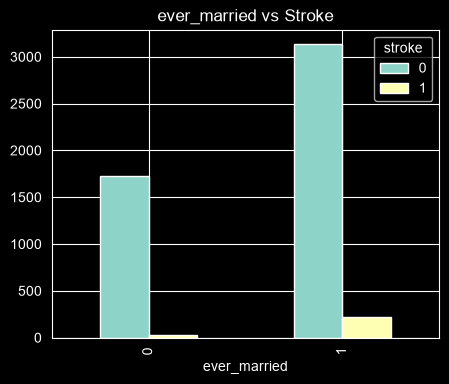

In [325]:
for col in binary_cols:
    pd.crosstab(df[col], df["stroke"]).plot(
        kind="bar",
        figsize=(5, 4)
    )

    plt.title(f"{col} vs Stroke")

    plt.show()

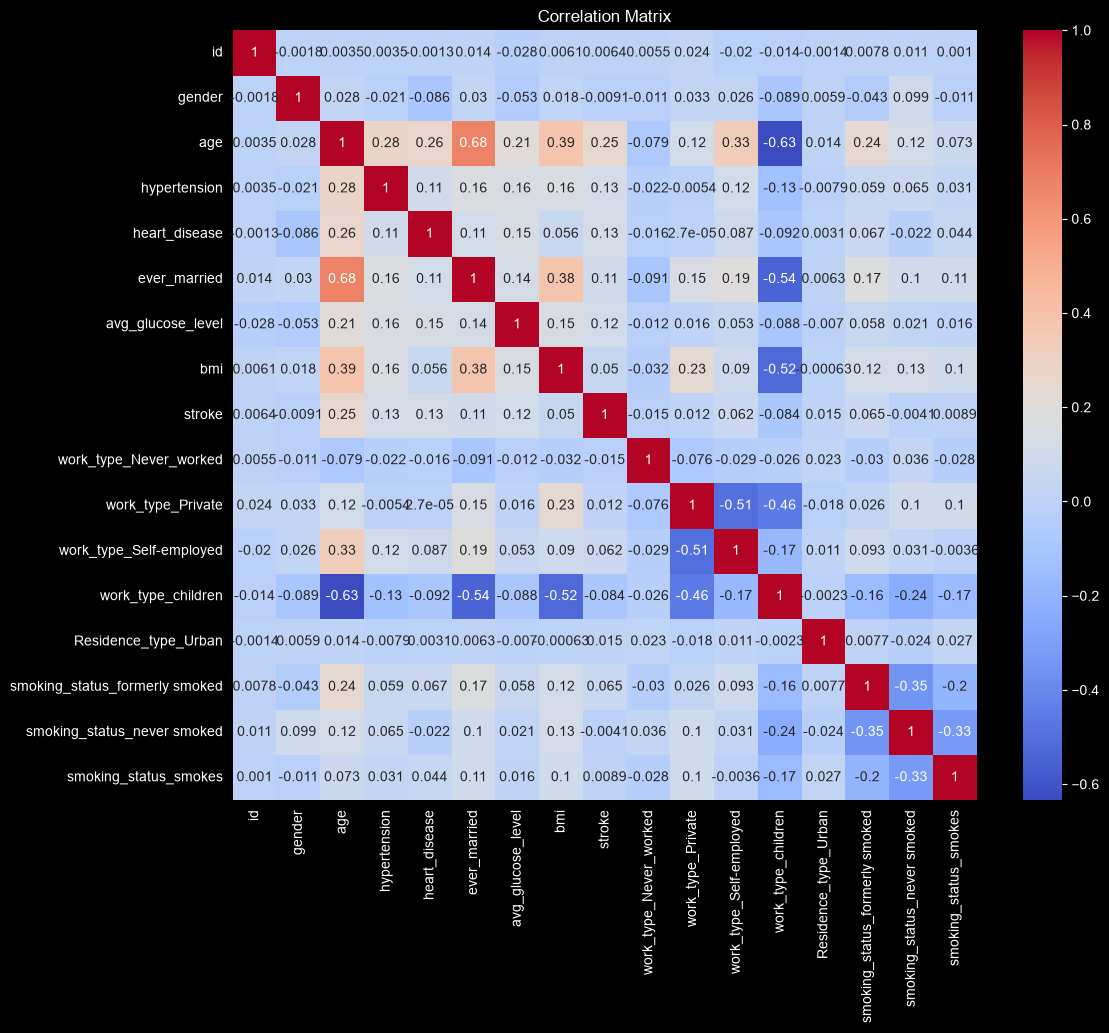

In [326]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [327]:
corr = df.corr(numeric_only=True)["stroke"].sort_values(ascending=False)
corr

stroke                            1.000000
age                               0.245257
heart_disease                     0.134914
hypertension                      0.127904
avg_glucose_level                 0.117180
ever_married                      0.108340
smoking_status_formerly smoked    0.064556
work_type_Self-employed           0.062168
bmi                               0.050075
Residence_type_Urban              0.015458
work_type_Private                 0.011888
smoking_status_smokes             0.008939
id                                0.006388
smoking_status_never smoked      -0.004129
gender                           -0.009117
work_type_Never_worked           -0.014882
work_type_children               -0.083869
Name: stroke, dtype: float64

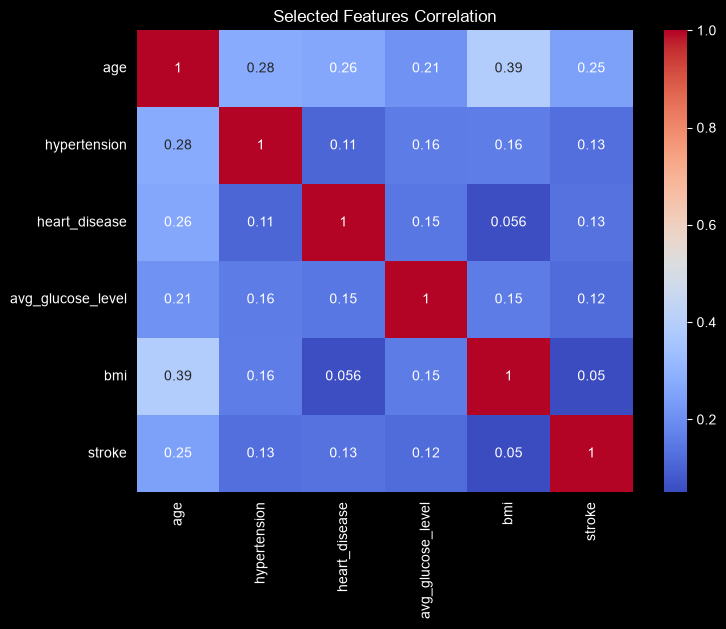

In [328]:
selected_features = [
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi",
    "stroke"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[selected_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Selected Features Correlation")

plt.show()

# **Feature Selection**

In [329]:
df.drop("id", axis=1, inplace=True)

In [330]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'avg_glucose_level', 'bmi', 'stroke', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'Residence_type_Urban', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='str')

In [331]:
X = df.drop("stroke", axis=1)

y = df["stroke"]

In [332]:
X.shape

(5110, 15)

In [333]:
y.shape

(5110,)

# **Train-Test Split**

In [334]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [335]:
X_train.shape

(4088, 15)

In [336]:
y_train.shape

(4088,)

In [337]:
X_test.shape

(1022, 15)

In [338]:
y_test.shape

(1022,)

# **Feature Scaling**

In [339]:
scaler = RobustScaler()

In [340]:
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [341]:
X_train.shape

(4088, 15)

In [342]:
X_test.shape

(1022, 15)

# **Handle Class Imbalance (SMOTE)**

In [343]:
y_train.value_counts()

stroke
0    3889
1     199
Name: count, dtype: int64

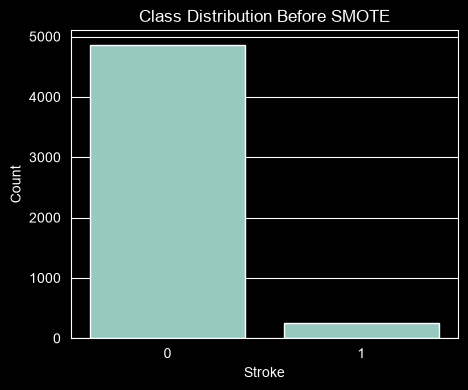

In [344]:
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

In [345]:
sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(
    X_train,
    y_train
)

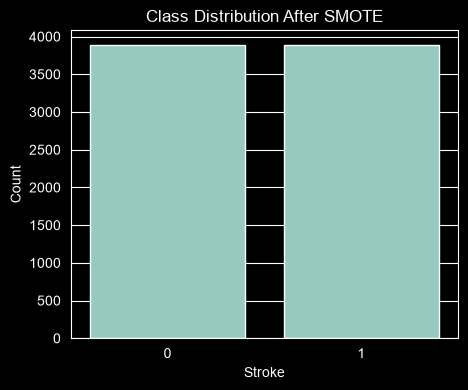

In [346]:
plt.figure(figsize=(5,4))
sns.countplot(x=y_train)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

In [347]:
y_train.value_counts()

stroke
0    3889
1    3889
Name: count, dtype: int64

In [348]:
before = y.value_counts().rename("Before SMOTE")
after = y_train.value_counts().rename("After SMOTE")

pd.concat([before, after], axis=1)

,Before SMOTE,After SMOTE
stroke,,
0,4861,3889
1,249,3889


# **Logistic Regression**

In [349]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [350]:
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [351]:
y_pred = log_model.predict(X_test)

In [352]:
y_prob = log_model.predict_proba(X_test)[:, 1]

In [353]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob) * 100:.2f}%")

Accuracy  : 74.76%
Precision : 13.89%
Recall    : 80.00%
F1 Score  : 23.67%
ROC AUC   : 84.49%


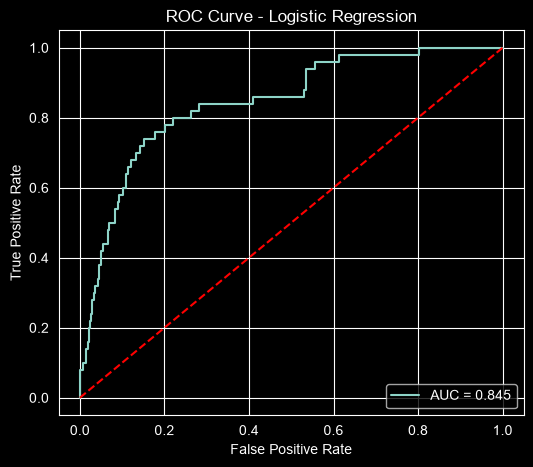

In [354]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")

plt.show()

In [355]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[724 248]
 [ 10  40]]


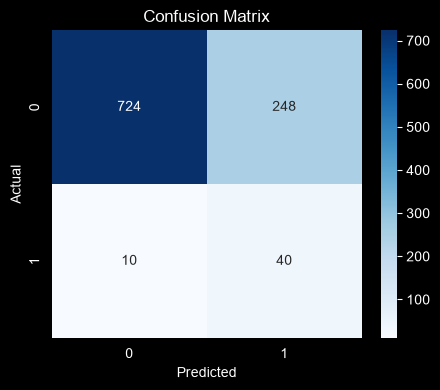

In [356]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [357]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



In [358]:
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score*100:.2f}%")

print(f"\nMean Accuracy: {scores.mean()*100:.2f}%")
print(f"Standard Deviation: {scores.std() * 100:.2f}%")

Fold 1: 95.11%
Fold 2: 95.11%
Fold 3: 95.11%
Fold 4: 95.01%
Fold 5: 95.30%

Mean Accuracy: 95.13%
Standard Deviation: 0.10%


In [359]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

In [360]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}


In [361]:
print("Best CV Score:")
print(f'{grid_search.best_score_*100:.2f}%')

Best CV Score:
79.28%


In [362]:
best_model = grid_search.best_estimator_

In [363]:
y_pred = best_model.predict(X_test)

In [364]:
y_prob = best_model.predict_proba(X_test)[:, 1]

In [365]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.735812133072407
Precision: 0.1357615894039735
Recall   : 0.82
F1 Score : 0.23295454545454544
ROC AUC  : 0.8441975308641976


In [366]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.14      0.82      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.78      0.54      1022
weighted avg       0.95      0.74      0.81      1022



# **Decision Tree**

In [367]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [368]:
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [369]:
y_pred = dt_model.predict(X_test)

In [370]:
y_prob = dt_model.predict_proba(X_test)[:, 1]

In [371]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob) * 100:.2f}%")

Accuracy  : 88.55%
Precision : 9.64%
Recall    : 16.00%
F1 Score  : 12.03%
ROC AUC   : 54.14%


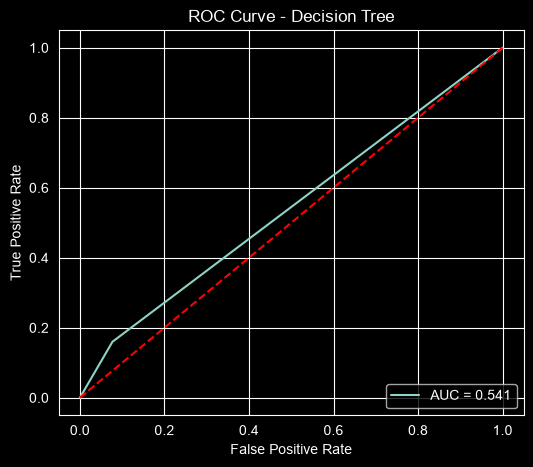

In [372]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend(loc="lower right")

plt.show()

In [373]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[897,  75],
       [ 42,   8]])

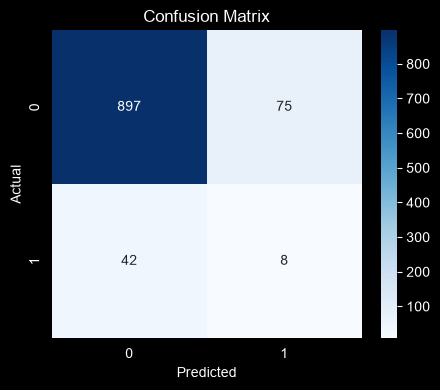

In [374]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [375]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       972
           1       0.10      0.16      0.12        50

    accuracy                           0.89      1022
   macro avg       0.53      0.54      0.53      1022
weighted avg       0.91      0.89      0.90      1022



In [376]:
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

scores = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score*100:.2f}%")

print(f"\nMean Accuracy: {scores.mean()*100:.2f}%")
print(f"Standard Deviation: {scores.std() * 100:.2f}%")

Fold 1: 90.90%
Fold 2: 91.59%
Fold 3: 90.80%
Fold 4: 91.98%
Fold 5: 91.29%

Mean Accuracy: 91.31%
Standard Deviation: 0.43%


In [377]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and param

In [378]:
print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [379]:
print(f'{grid.best_score_*100:.2f}%')

92.15%


In [380]:
best_dt = grid.best_estimator_

In [381]:
y_pred = best_dt.predict(X_test)

In [382]:
y_prob = best_dt.predict_proba(X_test)[:, 1]

In [383]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob) * 100:.2f}%")

Accuracy  : 90.70%
Precision : 10.53%
Recall    : 12.00%
F1 Score  : 11.21%
ROC AUC   : 53.38%


In [384]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       972
           1       0.11      0.12      0.11        50

    accuracy                           0.91      1022
   macro avg       0.53      0.53      0.53      1022
weighted avg       0.91      0.91      0.91      1022



# **Random Forest**

In [385]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

In [386]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [387]:
y_pred = rf_model.predict(X_test)

In [388]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

In [389]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob) * 100:.2f}%")

Accuracy  : 92.47%
Precision : 15.38%
Recall    : 12.00%
F1 Score  : 13.48%
ROC AUC   : 77.48%


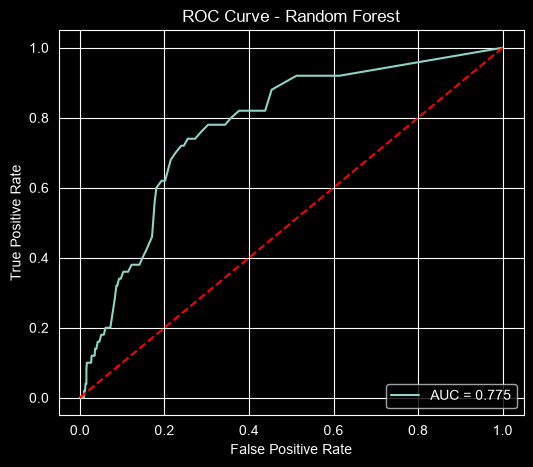

In [390]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")

plt.show()

In [391]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[939,  33],
       [ 44,   6]])

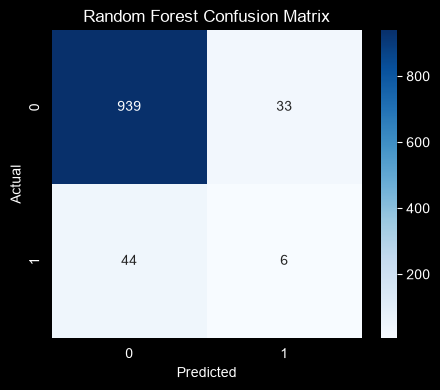

In [392]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [393]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.15      0.12      0.13        50

    accuracy                           0.92      1022
   macro avg       0.55      0.54      0.55      1022
weighted avg       0.92      0.92      0.92      1022



In [394]:
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

scores = cross_val_score(
    RandomForestClassifier(random_state=42),
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score * 100:.2f}%")

print(f"\nMean Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {scores.std() * 100:.2f}%")

Fold 1: 94.72%
Fold 2: 94.91%
Fold 3: 94.91%
Fold 4: 95.01%
Fold 5: 95.11%

Mean Accuracy: 94.93%
Standard Deviation: 0.13%


In [395]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [396]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [397]:
print(f'{grid.best_score_*100:.2f}%')

97.05%


In [398]:
best_rf = grid.best_estimator_

In [399]:
y_pred = best_rf.predict(X_test)

In [400]:
y_prob = best_rf.predict_proba(X_test)[:, 1]

In [401]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob) * 100:.2f}%")

Accuracy  : 92.86%
Precision : 15.15%
Recall    : 10.00%
F1 Score  : 12.05%
ROC AUC   : 78.60%


In [402]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       972
           1       0.15      0.10      0.12        50

    accuracy                           0.93      1022
   macro avg       0.55      0.54      0.54      1022
weighted avg       0.92      0.93      0.92      1022



# **Support Vector Machine (SVM)**

In [403]:
svm_model = SVC(
    probability=True,
    random_state=42
)

In [404]:
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [405]:
y_pred = svm_model.predict(X_test)

In [406]:
y_prob = svm_model.predict_proba(X_test)[:, 1]

In [407]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob) * 100:.2f}%")

Accuracy  : 80.33%
Precision : 11.68%
Recall    : 46.00%
F1 Score  : 18.62%
ROC AUC   : 78.65%


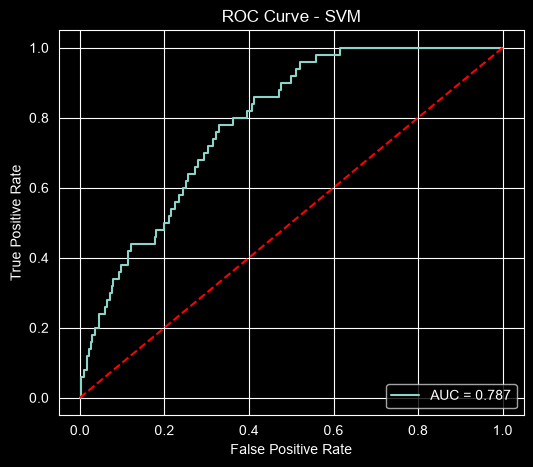

In [408]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc="lower right")

plt.show()

In [409]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[798, 174],
       [ 27,  23]])

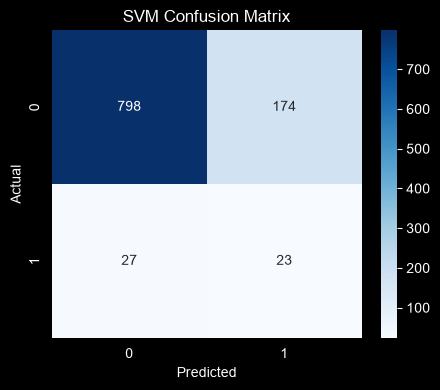

In [410]:
plt.figure(figsize=(5, 4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [411]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89       972
           1       0.12      0.46      0.19        50

    accuracy                           0.80      1022
   macro avg       0.54      0.64      0.54      1022
weighted avg       0.93      0.80      0.85      1022



In [412]:
scores = cross_val_score(
    SVC(probability=True, random_state=42),
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

for i, score in enumerate(scores):
    print(f"Fold {i + 1}: {score * 100:.2f}%")

print(f"\nMean Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {scores.std() * 100:.2f}%")

Fold 1: 95.11%
Fold 2: 95.11%
Fold 3: 95.11%
Fold 4: 95.11%
Fold 5: 95.21%

Mean Accuracy: 95.13%
Standard Deviation: 0.04%


In [413]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probabili...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [414]:
print(grid.best_params_)

{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [415]:
print(f'{grid.best_score_*100:.2f}%')

95.00%


In [416]:
best_svm = grid.best_estimator_

In [417]:
y_pred = best_svm.predict(X_test)

In [418]:
y_prob = best_svm.predict_proba(X_test)[:,1]

In [419]:
print(f"Accuracy  : {accuracy_score(y_test,y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test,y_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test,y_pred)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test,y_pred)*100:.2f}%")
print(f"ROC AUC   : {roc_auc_score(y_test,y_prob)*100:.2f}%")

Accuracy  : 88.75%
Precision : 14.29%
Recall    : 26.00%
F1 Score  : 18.44%
ROC AUC   : 75.25%


In [420]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       972
           1       0.14      0.26      0.18        50

    accuracy                           0.89      1022
   macro avg       0.55      0.59      0.56      1022
weighted avg       0.92      0.89      0.90      1022



# **K-Nearest Neighbors (KNN)**

In [421]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [422]:
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [423]:
y_pred = knn_model.predict(X_test)

In [424]:
print(f"Accuracy  : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob) * 100:.2f}%")

Accuracy  : 82.97%
Precision : 13.10%
Recall    : 44.00%
F1 Score  : 20.18%
ROC AUC   : 75.25%


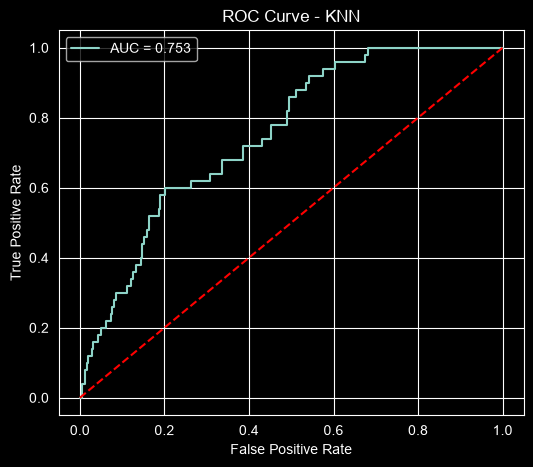

In [425]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()

plt.show()

In [426]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[826, 146],
       [ 28,  22]])

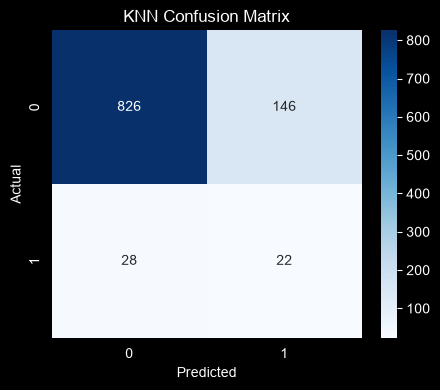

In [427]:
plt.figure(figsize=(5, 4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [428]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90       972
           1       0.13      0.44      0.20        50

    accuracy                           0.83      1022
   macro avg       0.55      0.64      0.55      1022
weighted avg       0.93      0.83      0.87      1022



In [429]:
scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X_scaled,
    y,
    cv=5,
    scoring="accuracy"
)

for i, score in enumerate(scores):
    print(f"Fold {i + 1}: {score * 100:.2f}%")

print(f"\nMean Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {scores.std() * 100:.2f}%")

Fold 1: 94.81%
Fold 2: 94.62%
Fold 3: 95.01%
Fold 4: 94.91%
Fold 5: 95.11%

Mean Accuracy: 94.89%
Standard Deviation: 0.17%


In [430]:
param_grid = {
    "n_neighbors": list(range(3, 31, 2)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

In [431]:
print(grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [432]:
print(f'{grid.best_score_*100:.2f}%')

94.78%


In [433]:
best_knn = grid.best_estimator_

In [434]:
y_pred = best_knn.predict(X_test)

In [435]:
y_prob = best_knn.predict_proba(X_test)[:,1]

In [436]:
print(f"Accuracy  : {accuracy_score(y_test,y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test,y_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test,y_pred)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test,y_pred)*100:.2f}%")
print(f"ROC AUC   : {roc_auc_score(y_test,y_prob)*100:.2f}%")

Accuracy  : 89.14%
Precision : 14.12%
Recall    : 24.00%
F1 Score  : 17.78%
ROC AUC   : 59.47%


In [437]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       972
           1       0.14      0.24      0.18        50

    accuracy                           0.89      1022
   macro avg       0.55      0.58      0.56      1022
weighted avg       0.92      0.89      0.90      1022



In [438]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Accuracy": [75, 89, 92, 80.33, 82.97],
    "Precision": [14, 10, 15, 11.68, 13.10],
    "Recall": [80, 16, 12, 46.00, 44.00],
    "F1-Score": [24, 12, 13, 18.62, 20.18],
    "ROC AUC": [82, 64, 70, 78.65, 75.25]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1-Score  ROC AUC
0  Logistic Regression     75.00      14.00    80.0     24.00    82.00
1        Decision Tree     89.00      10.00    16.0     12.00    64.00
2        Random Forest     92.00      15.00    12.0     13.00    70.00
3                  SVM     80.33      11.68    46.0     18.62    78.65
4                  KNN     82.97      13.10    44.0     20.18    75.25


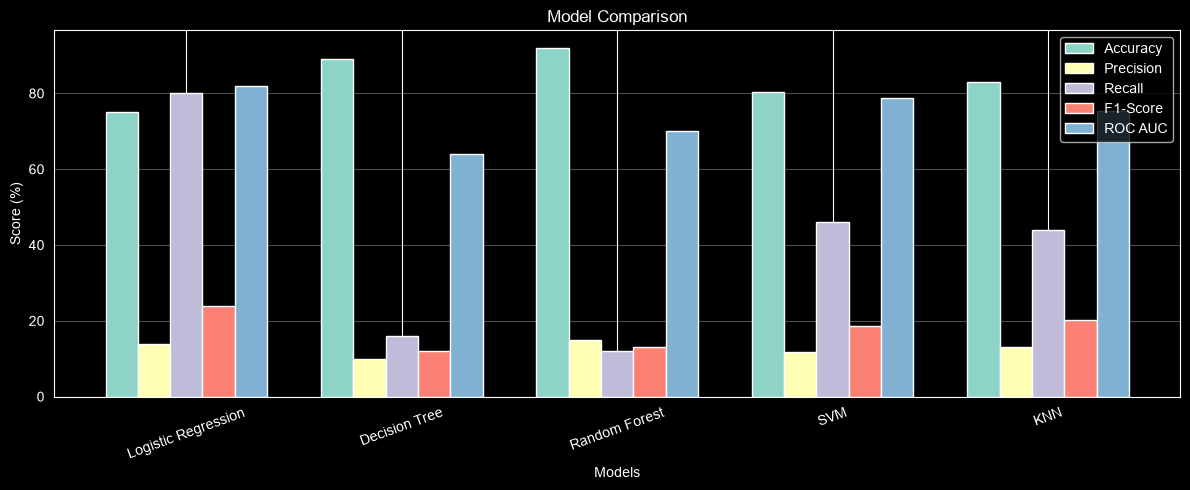

In [453]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]

x = np.arange(len(results["Model"]))
width = 0.15

plt.figure(figsize=(12, 5))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        results[metric],
        width,
        label=metric
    )

plt.xlabel("Models")
plt.ylabel("Score (%)")
plt.title("Model Comparison")
plt.xticks(
    x + width * 2,
    results["Model"],
    rotation=20
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

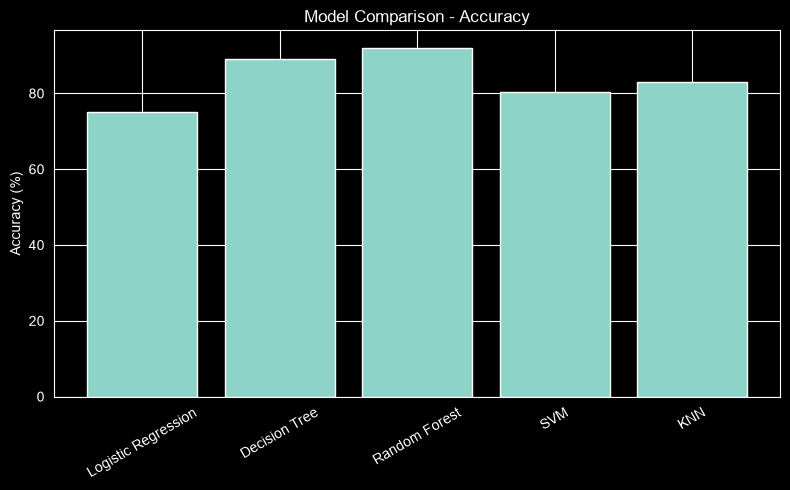

In [439]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

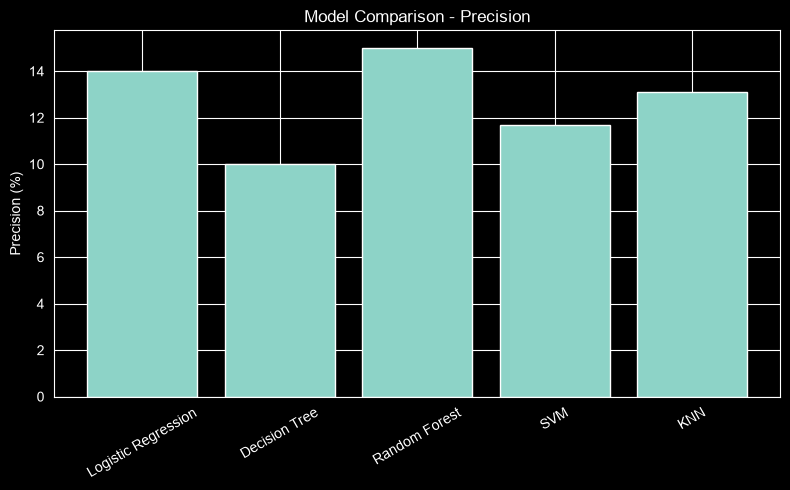

In [440]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Precision"])
plt.title("Model Comparison - Precision")
plt.ylabel("Precision (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

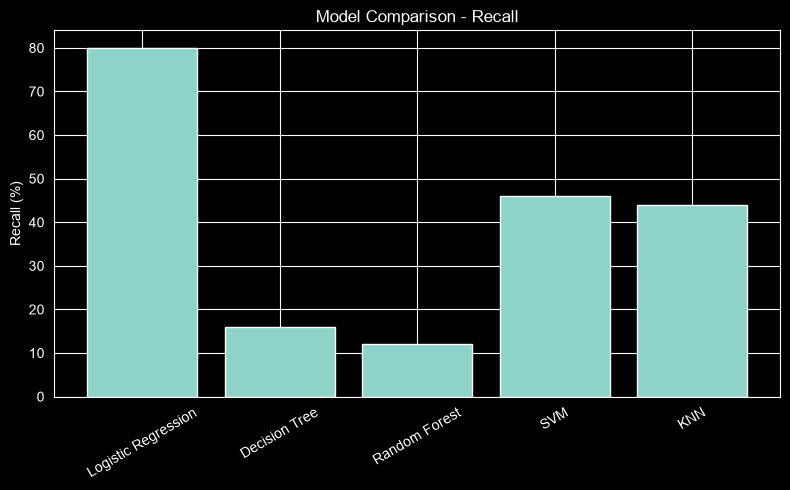

In [441]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Recall"])
plt.title("Model Comparison - Recall")
plt.ylabel("Recall (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

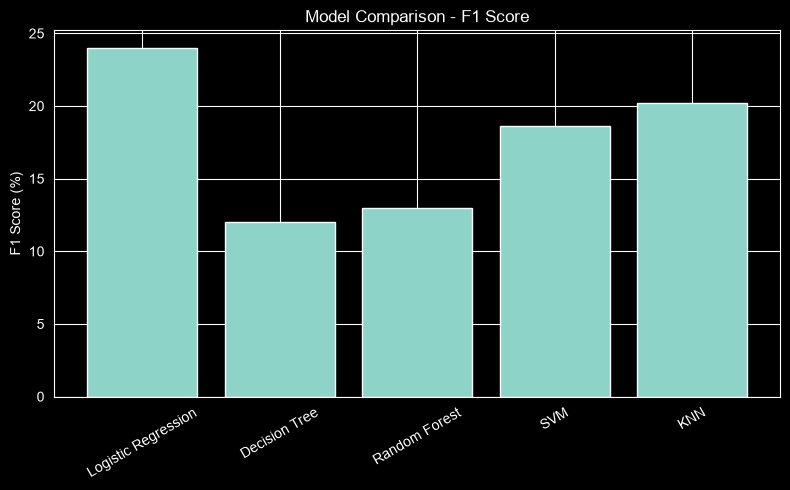

In [442]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["F1-Score"])
plt.title("Model Comparison - F1 Score")
plt.ylabel("F1 Score (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

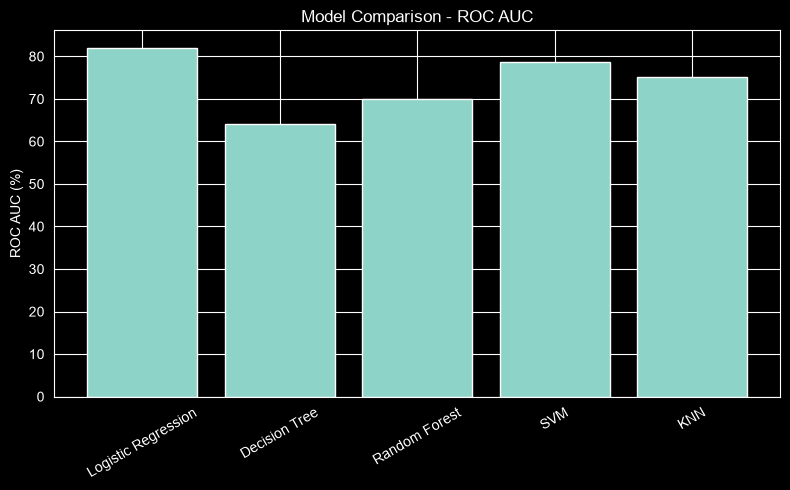

In [443]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["ROC AUC"])
plt.title("Model Comparison - ROC AUC")
plt.ylabel("ROC AUC (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [444]:
best_model = results.loc[results["F1-Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                    75.0
Precision                   14.0
Recall                      80.0
F1-Score                    24.0
ROC AUC                     82.0
Name: 0, dtype: object


In [445]:
best_model = results.loc[results["Recall"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                    75.0
Precision                   14.0
Recall                      80.0
F1-Score                    24.0
ROC AUC                     82.0
Name: 0, dtype: object


In [446]:
best_model = results.loc[results["ROC AUC"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model        Logistic Regression
Accuracy                    75.0
Precision                   14.0
Recall                      80.0
F1-Score                    24.0
ROC AUC                     82.0
Name: 0, dtype: object


# **Deployment**
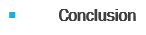

In [447]:
joblib.dump(log_model, "stroke_model.pkl")

['stroke_model.pkl']

In [448]:
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [449]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, "features.pkl")
joblib.dump(feature_names, "features.pkl")

['features.pkl']